# 从零实现Transformer 核心模块
## 阶段0: 环境检测与导入

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import math
import copy
import random
import matplotlib.pyplot as plt
import time
from datasets import load_dataset
import sentencepiece as spm
import tempfile
from datetime import timedelta
from dataclasses import dataclass
from torch.optim import Adam
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import Sampler
from collections import Counter

In [2]:
# 检查GPU是否可用
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
  print(f"GPU: {torch.cuda.get_device_name(0)}")
  print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("No GPU available, using CPU")

# 设置随机种子, 保证可以复现
torch.manual_seed(42)
np.random.seed(42)

GPU: NVIDIA GeForce RTX 4060 Laptop GPU
GPU Memory: 8.59 GB


## 阶段1: Embedding


### 1.1 Token Embedding

In [3]:
class Embeddings(nn.Module):
  def __init__(self, vocab_size:int, d_model:int):
    super().__init__()
    self.d_model = d_model
    self.lut = nn.Embedding(vocab_size, d_model) # W_E: (vocab_szie, d_model)
    # X @ W_E 不合法是因为这里不是在做矩阵乘法
    # Y[b, t, :] = W_E(X[b, t, :]) 实际上时在索引

  def forward(self, x:torch.Tensor) -> torch.Tensor:
    """
    x: (batch_size, seq_len)
    return: (batch_size, seq_len, d_model)
    """
    return self.lut(x) * math.sqrt(self.d_model)


### 1.2 Positional Encoding

In [4]:
class PositionalEncoding(nn.Module):
  def __init__(self, d_model:int, dropout:float=0.0, max_len:int=5000):
    super().__init__()
    self.dropout = nn.Dropout(p=dropout)

    pe = torch.zeros(max_len, d_model)
    # position: (max_len, 1)
    position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

    # div_term: (1, d_model/2)
    div_term = torch.exp(
        torch.arange(0, d_model, 2, dtype=torch.float)
        * (-math.log(10000) / d_model)
    ).unsqueeze(0)


    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)

    pe = pe.unsqueeze(0) # ->(1, max_len, d_model) 方便与batch相加(广播机制)

    # 注册为buffer
    self.register_buffer("pe", pe)

  def forward(self, x:torch.Tensor) -> torch.Tensor:
    x = x + self.pe[:, :x.size(1)] # x; (batch_size, seq_len, d_modle) 即上面embed的输出
    return self.dropout(x)

## 阶段2: Attention机制

### 1.1 Scaled Dot-Product Attention
$$
   \mathrm{Attention}(Q, K, V) = \mathrm{softmax}(\frac{QK^T}{\sqrt{d_k}})V
$$


In [5]:
def attention(query, key, value, mask=None, dropout=None):
  """
  计算缩放点积 Scaled Dot-Product Attention
  query: (batch, headi, seq_len_q, d_k)
  key:   (batch, headi, seq_len_k, d_k)
  value: (batch, headi, seq_len_k, d_v)
  mask:  (batch, 1 or headi, seq_len_q, seq_len_k) padding mask or subsequent mask
  output: (batch, h, seq_len_q, seq_len_k)
  """
  d_k = query.size(-1)

  # 1. QK^T / sqrt(kd)
  scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)# scores: (batch, h, seq_q, seq_k)

  # 2. mask(被mask的位置为-inf)
  if mask is not None:
    mask = mask.to(torch.bool)
    scores = scores.masked_fill(~mask, float('-inf'))


  # 3. softmax
  attention_weights = F.softmax(scores, dim=-1)

  # 4.dropout
  if dropout is not None:
    attention_weights = dropout(attention_weights)

  # V的加权求和
  output = torch.matmul(attention_weights, value)

  return output, attention_weights


### 2.2 Multi-Head Attention

$$
\mathrm{MultiHead}(Q, K, V) =
    \mathrm{Concat}(\mathrm{head_1}, ..., \mathrm{head_h})W^O \\
    \text{where}~\mathrm{head_i} = \mathrm{Attention}(QW^Q_i, KW^K_i, VW^V_i)
$$

Where the projections are parameter matrices $W^Q_i \in
\mathbb{R}^{d_{\text{model}} \times d_k}$, $W^K_i \in
\mathbb{R}^{d_{\text{model}} \times d_k}$, $W^V_i \in
\mathbb{R}^{d_{\text{model}} \times d_v}$ and $W^O \in
\mathbb{R}^{hd_v \times d_{\text{model}}}$.


In [6]:
class MultiHeadAttention(nn.Module):
  def __init__(self, d_model, num_heads, dropout=0.0):
    super().__init__()
    assert d_model % num_heads == 0

    self.d_model = d_model
    self.h = num_heads
    self.d_k = d_model // num_heads

    # 四个Linear networks, 每个的大小是(512, 8*64)的
    self.W_q = nn.Linear(d_model, d_model)
    self.W_k = nn.Linear(d_model, d_model)
    self.W_v = nn.Linear(d_model, d_model)
    self.W_o = nn.Linear(d_model, d_model)

    self.dropout = nn.Dropout(dropout)

  def forward(self, query, key, value, mask=None):
    batch_size, seq_len_q, _ = query.size()
    seq_len_k = key.size(1)

    # 我们假设d_k == d_v
    assert key.size(1) == value.size(1)

    # 1. 线性映射
    # x;(batch seq_len, d_model) @ W:(d_model, d_model) -> (batch seq_len, d_model)
    Q = self.W_q(query)
    K = self.W_k(key)
    V = self.W_v(value)

    #2. 分头
    Q = Q.view(batch_size, seq_len_q, self.h, self.d_k).transpose(1, 2)
    K = K.view(batch_size, seq_len_k, self.h, self.d_k).transpose(1, 2)
    V = V.view(batch_size, seq_len_k, self.h, self.d_k).transpose(1, 2) # [batch, h, seq_len, d_k]

    # 3. 计算注意力得分
    out, attn = attention(Q, K, V, mask=mask, dropout=self.dropout)

    # 4. 合并
    out = out.transpose(1, 2).contiguous()
    out = out.view(batch_size, seq_len_q, -1) # [batch, seq_len, d_model]

    # 5. 投影
    out = self.W_o(out)

    return out, attn

### 2.3 mask

In [7]:
def make_src_mask(src, pad_idx=0):
  """
  encoder padding mask
  src: (batch, src_seq_len)
  只需要mask掉key为PAD的列。
  就算存在Query 的PAD行，但是传递到下一层，
  非PAD的行与PAD的列计算，得到的被污染的列，会被mask，
  而PAD的行与非PAD的列计算，得到被污染的行，没有被mask会继续将污染传递到最后，
  但是最后在计算loss的时候，也会被ignore
  """
  batch_size, seq_len = src.size()
  mask = (src != pad_idx).unsqueeze(1).unsqueeze(2) # mask: (batch, 1, 1, src_seq_len)
  mask = mask.expand(batch_size, 1, seq_len, seq_len).contiguous()
  return mask

def make_tgt_mask(tgt, pad_idx=0):
  """
  decoder padding + subsequent mask
  tgt: (batch, tgt_seq_len)
  """
  batch_size, seq_len = tgt.size()

  # padding mask
  padding_mask = (tgt != pad_idx).unsqueeze(1).unsqueeze(2) # (batch, 1, 1, tgt_seq_len) 
  # subsequent mask
  subsequent_mask = torch.tril(
      torch.ones((seq_len, seq_len), device=tgt.device, dtype=torch.bool)
  ).unsqueeze(0).unsqueeze(0) # (1, 1, tgt_seq_len, tgt_seq_len)

  mask = (padding_mask & subsequent_mask).bool() # (batch, 1, seq_len ,seq_len)

  return mask


def make_cross_attn_mask(src, tgt, pad_idx=0):
  """
  Decoder cross-attention mask
  src: (batch, src_seq_len)
  tgt: (batch, tgt_seq_len)
  return: (batch, 1, tgt_seq_len, src_seq_len)
  """
  batch_size = src.size(0)
  src_len = src.size(1)
  tgt_len = tgt.size(1)

  # Src padding mask: (batch, 1, 1, src_len)
  src_mask = (src != pad_idx).unsqueeze(1).unsqueeze(2)

  # 扩展到 (batch, 1, tgt_len, src_len)
  mask = src_mask.expand(batch_size, 1, tgt_len, src_len)
  return mask

## 阶段3: Position-wise FFN

$$\mathrm{FFN}(x)=\max(0, xW_1 + b_1) W_2 + b_2$$


In [8]:
class PositionwiseFeedForward(nn.Module):
  def __init__(self, d_model, d_ff=2048, dropout=0.0):
    super().__init__()
    self.linear1 = nn.Linear(d_model, d_ff)
    self.linear2 = nn.Linear(d_ff, d_model)
    self.dropout = nn.Dropout(p=dropout)

  """
  x = W1x + b1
  x = ReLu(x)
  x = dropout(x)
  x = W2x + b2
  """
  def forward(self, x):
    return self.linear2(
        self.dropout(
            F.relu(self.linear1(x))
        )
    )

## 阶段4: Encoder

### 4.1 Encoder Layer

In [9]:
class LayerNorm(nn.Module):
  def __init__(self, features, eps=1e-6): # features == d_model
    super().__init__()
    self.a_2 = nn.Parameter(torch.ones(features))
    self.b_2 = nn.Parameter(torch.zeros(features))
    self.eps = eps

  def forward(self, x):
    mean = x.mean(-1, keepdim=True)
    std = x.std(-1, keepdim=True)
    return self.a_2 * (x - mean) / (std + self.eps) + self.b_2

In [10]:
class SublayerConnection(nn.Module):
  # 层归一化 + 残差连接 Add&Norm
  def __init__(self, size, dropout):
    super().__init__()
    self.norm = LayerNorm(size)
    self.dropout = nn.Dropout(dropout)

  def forward(self, x, sublayer):
    # sublayer: self-attn or ffn
    return x + self.dropout(sublayer(self.norm(x)))

In [11]:
class EncoderLayer(nn.Module):
  def __init__(self, size, self_attn, feed_forward, dropout=0.0):
    super().__init__()
    self.self_attn = self_attn
    self.feed_forward = feed_forward

    self.sublayer = nn.ModuleList([
        SublayerConnection(size, dropout),
        SublayerConnection(size, dropout)
    ])

    self.size = size

  def forward(self, x, mask):
    # 1. x' = x + self-attention(LN(x))
    x = self.sublayer[0](
        x,
        lambda x: self.self_attn(x, x, x, mask)[0]
    )
    # 2. x' + FFN(LN(x))
    return self.sublayer[1](x, self.feed_forward)


### 4.2 Encoder Stack

In [12]:
class Encoder(nn.Module):
  def __init__(self, layer, N):
    super().__init__()
    self.layers = nn.ModuleList([
      copy.deepcopy(layer) for _ in range(N)
    ])
    self.norm = LayerNorm(layer.size)

  def forward(self, x, mask):
    for layer in self.layers:
      x = layer(x, mask)
    return self.norm(x)

## 阶段5: Decoder

### 5.1 Decoder Layer

In [13]:
class DecoderLayer(nn.Module):
    def __init__(self, size, self_attn, src_attn, feed_forward, dropout=0.0):
      super().__init__()
      self.self_attn = self_attn
      self.src_attn = src_attn
      self.feed_forward = feed_forward

      self.sublayer = nn.ModuleList([
          SublayerConnection(size, dropout), # self-attn
          SublayerConnection(size, dropout), # cross-attn
          SublayerConnection(size, dropout), # ffn
      ])

      self.size = size

    def forward(self, x, memory, src_mask, tgt_mask):
      m = memory
      # 1. 第一个子层连接：自注意力机制 x = x + self-attention(LN(x))
      x = self.sublayer[0](
          x,
          lambda x: self.self_attn(x, x, x, tgt_mask)[0]
        )
      # 2. 第二个子层连接：交叉注意力机制 x = x + cross-attention(LN(x))
      x = self.sublayer[1](
          x,
          lambda x: self.src_attn(x, m, m, src_mask)[0]
        )

      # 3. 第三个子层连接：前馈神经网络 x + FFN(LN(x))
      return self.sublayer[2](x, self.feed_forward)

### 2.2 Decoder Stack

In [14]:
class Decoder(nn.Module):
  def __init__(self, layer, N):
    super().__init__()
    self.layers = nn.ModuleList([
        copy.deepcopy(layer) for _ in range(N)
    ])
    self.norm = LayerNorm(layer.size)

  def forward(self, x, memory, src_mask, tgt_mask):
    for layer in self.layers:
      x = layer(x, memory, src_mask, tgt_mask)
    return self.norm(x)

## 阶段6: Generator


In [15]:
# decoder的hidden state转为概率分布
class Generator(nn.Module):
  def __init__(self, d_model, vocab_size):
    super().__init__()
    self.proj = nn.Linear(d_model, vocab_size)

  def forward(self, x):
    #return F.log_softmax(self.proj(x), dim=-1)
    return self.proj(x) # logits

## 阶段7: 组装Transformer

In [16]:
class Transformer(nn.Module):
  def __init__(self,
         src_vocab_size,
         tgt_vocab_size,
         d_model,
         d_ff,
         N,
         h,
         dropout):
    super().__init__()
    self.src_vocab_size = src_vocab_size
    self.tgt_vocab_size = tgt_vocab_size
    self.d_model = d_model

    self.src_embed = nn.Sequential(
        Embeddings(src_vocab_size, d_model),
        PositionalEncoding(d_model, dropout)
    )

    self.tgt_embed = nn.Sequential(
        Embeddings(tgt_vocab_size, d_model),
        PositionalEncoding(d_model, dropout)
    )

    self.encoder = Encoder(
        EncoderLayer(d_model,
               MultiHeadAttention(d_model, h),
               PositionwiseFeedForward(d_model, d_ff),
               dropout),
        N
    )

    self.decoder = Decoder(
        DecoderLayer(d_model,
               MultiHeadAttention(d_model, h),
               MultiHeadAttention(d_model, h),
               PositionwiseFeedForward(d_model, d_ff),
               dropout),
        N
    )

    self.generator = Generator(d_model, tgt_vocab_size)
    
    self._init_weights()
    self._tie_weights()

  def _init_weights(self):
    # 初始化模型权重
    for p in self.parameters():
      if p.dim() > 1:
        nn.init.xavier_uniform_(p)

    # 特别处理嵌入层
    nn.init.normal_(self.src_embed[0].lut.weight, mean=0, std=self.d_model ** -0.5)
    nn.init.normal_(self.tgt_embed[0].lut.weight, mean=0, std=self.d_model ** -0.5)


  def _tie_weights(self):
    self.generator.proj.weight = self.tgt_embed[0].lut.weight
    self.generator.proj.weight.requires_grad = True

  def forward(self, src, tgt, src_mask, tgt_mask, cross_attn_mask):
    enc_output = self.encoder(self.src_embed(src), src_mask)
    dec_output = self.decoder(
        self.tgt_embed(tgt),
        enc_output,
        cross_attn_mask,
        tgt_mask
      )

    logits = self.generator(dec_output)
    return logits #(batch, seq_len, tgt_vocab_size)

## 阶段8 : 优化器

In [17]:
# Warmup: 线性增长
# lr = d_model^(-0.5) * min(step^(-0.5), step * warmup_steps^(-1.5))
def make_noam_lambda(d_model, warmup, factor=1.0):
  def rate(step):
    step = max(step, 1)
    return factor * (
        d_model ** (-0.5) * min(step ** (-0.5), step * warmup ** (-1.5))
    )
  return rate

# 数据处理

In [18]:
from pathlib import Path
import sentencepiece as spm

# =========================
# 全局配置（实验基准）
# =========================
RAW_DIR = Path("data/zh-en")          # IWSLT17 原始数据
OUT_DIR = Path("data/processed")      # 处理后数据
SP_DIR  = OUT_DIR / "spm"             # SentencePiece 目录

TRAIN_SAMPLES = 200_000               # 训练样本上限
VOCAB_SIZE = 30_000
CHAR_COVERAGE = 0.9995                # 中文必须高
MODEL_TYPE = "bpe"                    # 明确使用 BPE

OUT_DIR.mkdir(parents=True, exist_ok=True)
SP_DIR.mkdir(parents=True, exist_ok=True)

In [19]:
def extract_sentences(fp: Path):
    sentences = []
    with open(fp, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith("<seg"):
                start = line.find(">")
                end = line.find("</seg>")
                if start != -1 and end != -1:
                    sent = line[start + 1:end].strip()
                    if sent:
                        sentences.append(sent)
            elif not line.startswith("<"):
                sentences.append(line)
    return sentences


In [20]:
FILES = ["train.zh", "train.en", "valid.zh", "valid.en", "test.zh", "test.en"]

cache_ok = all((OUT_DIR / f).exists() for f in FILES)
if cache_ok:
    print("使用已缓存的数据集")
else:
    print("构建 IWSLT17 数据集")

    # -------- train --------
    train_zh = extract_sentences(RAW_DIR / "train.tags.zh-en.zh")
    train_en = extract_sentences(RAW_DIR / "train.tags.zh-en.en")
    n_train = min(len(train_zh), len(train_en), TRAIN_SAMPLES)
    train_zh, train_en = train_zh[:n_train], train_en[:n_train]

    # -------- valid --------
    valid_zh = extract_sentences(RAW_DIR / "IWSLT17.TED.dev2010.zh-en.zh.xml")
    valid_en = extract_sentences(RAW_DIR / "IWSLT17.TED.dev2010.zh-en.en.xml")
    n_valid = min(len(valid_zh), len(valid_en))
    valid_zh, valid_en = valid_zh[:n_valid], valid_en[:n_valid]

    # -------- test --------
    test_zh, test_en = [], []
    for year in range(2010, 2016):
        zh_fp = RAW_DIR / f"IWSLT17.TED.tst{year}.zh-en.zh.xml"
        en_fp = RAW_DIR / f"IWSLT17.TED.tst{year}.zh-en.en.xml"
        if zh_fp.exists() and en_fp.exists():
            zh = extract_sentences(zh_fp)
            en = extract_sentences(en_fp)
            n = min(len(zh), len(en))
            test_zh.extend(zh[:n])
            test_en.extend(en[:n])

    # -------- save --------
    for name, zh, en in [
        ("train", train_zh, train_en),
        ("valid", valid_zh, valid_en),
        ("test",  test_zh,  test_en),
    ]:
        (OUT_DIR / f"{name}.zh").write_text("\n".join(zh), encoding="utf-8")
        (OUT_DIR / f"{name}.en").write_text("\n".join(en), encoding="utf-8")

    print(f"✓ 数据集完成 | train={n_train:,}, valid={n_valid:,}, test={len(test_zh):,}")


使用已缓存的数据集


In [21]:
sp_model_prefix = SP_DIR / "zh_en_bpe"

if (SP_DIR / "zh_en_bpe.model").exists():
    print("✓ 已存在 SentencePiece 模型，跳过训练")
else:
    print("▶ 训练 SentencePiece BPE")

    with open(OUT_DIR / "spm_train.txt", "w", encoding="utf-8") as f:
        for lang in ["zh", "en"]:
            with open(OUT_DIR / f"train.{lang}", encoding="utf-8") as fin:
                for line in fin:
                    f.write(line)

    spm.SentencePieceTrainer.train(
        input=str(OUT_DIR / "spm_train.txt"),
        model_prefix=str(sp_model_prefix),
        vocab_size=VOCAB_SIZE,
        model_type=MODEL_TYPE,
        character_coverage=CHAR_COVERAGE,
        bos_id=1,
        eos_id=2,
        unk_id=3,
        pad_id=0,
        user_defined_symbols=[]
    )

    print("✓ SentencePiece 训练完成")


✓ 已存在 SentencePiece 模型，跳过训练


In [22]:
class TranslationDataset(Dataset):
    """
    翻译数据集类
    返回: (src_ids, tgt_input_ids, tgt_output_ids)
    """
    def __init__(self, src_path, tgt_path, sp, max_len=128):
        self.sp = sp
        self.max_len = max_len
        
        # 读取数据
        with open(src_path, 'r', encoding='utf-8') as f:
            self.src_lines = [line.strip() for line in f if line.strip()]
        
        with open(tgt_path, 'r', encoding='utf-8') as f:
            self.tgt_lines = [line.strip() for line in f if line.strip()]
        
        assert len(self.src_lines) == len(self.tgt_lines), "源语言和目标语言句子数量不匹配"
        
    def __len__(self):
        return len(self.src_lines)
    
    def __getitem__(self, idx):
        src_text = self.src_lines[idx]
        tgt_text = self.tgt_lines[idx]
        
        # 编码为ID序列
        src_ids = self.sp.encode(src_text, out_type=int)
        tgt_ids = self.sp.encode(tgt_text, out_type=int)
        
        # 截断
        src_ids = src_ids[:self.max_len]
        tgt_ids = tgt_ids[:self.max_len]
        
        # 添加BOS和EOS
        src_ids = [self.sp.bos_id()] + src_ids + [self.sp.eos_id()]
        tgt_ids = [self.sp.bos_id()] + tgt_ids + [self.sp.eos_id()]
        
        # 目标序列: input去掉最后一个, output去掉第一个
        tgt_input = tgt_ids[:-1]
        tgt_output = tgt_ids[1:]
        
        return (
            torch.tensor(src_ids, dtype=torch.long),
            torch.tensor(tgt_input, dtype=torch.long),
            torch.tensor(tgt_output, dtype=torch.long)
        )


In [23]:
def make_collate_fn(pad_id):
    def collate_fn(batch):
        srcs, tgts_input, tgts_output = zip(*batch)

        srcs_padded = torch.nn.utils.rnn.pad_sequence(
            srcs, batch_first=True, padding_value=pad_id
        )
        tgts_input_padded = torch.nn.utils.rnn.pad_sequence(
            tgts_input, batch_first=True, padding_value=pad_id
        )
        tgts_output_padded = torch.nn.utils.rnn.pad_sequence(
            tgts_output, batch_first=True, padding_value=pad_id
        )

        return srcs_padded, tgts_input_padded, tgts_output_padded

    return collate_fn


In [24]:
class Batch:
    def __init__(
        self,
        src,
        tgt_input,
        tgt_y,
        pad_idx,
        make_src_mask_fn,
        make_tgt_mask_fn,
        make_cross_attn_mask_fn,
    ):
        self.src = src
        self.src_mask = make_src_mask_fn(src, pad_idx)

        self.tgt = tgt_input
        self.tgt_y = tgt_y

        self.tgt_mask = make_tgt_mask_fn(self.tgt, pad_idx)
        self.cross_attn_mask = make_cross_attn_mask_fn(src, self.tgt, pad_idx)

        self.ntokens = (self.tgt_y != pad_idx).sum().item()


# 训练和评估

In [25]:
from dataclasses import dataclass, field
from typing import List

@dataclass
class TrainState:
    """
    记录训练过程中的所有关键指标
    """
    # 基础计数器
    step: int = 0
    accum_step: int = 0
    samples: int = 0
    tokens: int = 0
    
    # 历史曲线（每个epoch记录一次）
    train_loss_history: List[float] = field(default_factory=list)
    val_loss_history: List[float] = field(default_factory=list)
    bleu_history: List[float] = field(default_factory=list)
    lr_history: List[float] = field(default_factory=list)
    
    # 最佳记录
    best_bleu: float = -1.0
    best_epoch: int = 0

In [26]:
import random
from torch.utils.data import Sampler

class BucketSampler(Sampler):
    """
    Token-based dynamic batching sampler.
    Each batch satisfies:
      sum(src_len + tgt_len) <= max_tokens
      batch_size <= max_batch_size
    """

    def __init__(
        self,
        dataset,
        max_tokens: int,
        max_batch_size: int = 64,
        shuffle: bool = True,
        drop_last: bool = False,
    ):
        self.dataset = dataset
        self.max_tokens = max_tokens
        self.max_batch_size = max_batch_size
        self.shuffle = shuffle
        self.drop_last = drop_last

        # 1. 预计算每个样本的 token 数
        self.lengths = []
        for i in range(len(dataset)):
            src_ids, tgt_input, _ = dataset[i]
            self.lengths.append(len(src_ids) + len(tgt_input))


        # 2. 按长度排序（小的先来，batch 更紧凑）
        indices = list(range(len(dataset)))
        indices.sort(key=lambda i: self.lengths[i])

        # 3. 构建 batch
        self.batches = []
        cur_batch = []
        cur_tokens = 0

        for idx in indices:
            seq_tokens = self.lengths[idx]

            # 如果单条样本就超过 max_tokens，直接单独成 batch
            if seq_tokens > self.max_tokens:
                if cur_batch:
                    self.batches.append(cur_batch)
                    cur_batch = []
                    cur_tokens = 0
                self.batches.append([idx])
                continue

            # 判断是否还能塞进当前 batch
            if (
                cur_tokens + seq_tokens > self.max_tokens
                or len(cur_batch) >= self.max_batch_size
            ):
                if cur_batch:
                    self.batches.append(cur_batch)
                cur_batch = [idx]
                cur_tokens = seq_tokens
            else:
                cur_batch.append(idx)
                cur_tokens += seq_tokens

        # 4. 收尾
        if cur_batch and (not drop_last or len(cur_batch) > 1):
            self.batches.append(cur_batch)

    def __iter__(self):
        if self.shuffle:
            random.shuffle(self.batches)
        for batch in self.batches:
            yield batch

    def __len__(self):
        return len(self.batches)


In [27]:
class BeamDecoder:
    """
    批量Beam Search解码器
    1. 批处理多个样本同时解码
    2. 向量化beam扩展
    3. 使用torch操作减少Python循环
    4. 缓存encoder输出
    """
    def __init__(
        self,
        sp,
        beam_size=4,
        max_len=50,
        length_penalty=1.0,
        batch_size=32,
    ):
        self.sp = sp
        self.beam_size = beam_size
        self.max_len = max_len
        self.length_penalty = length_penalty
        self.batch_size = batch_size
        
        self.pad_id = sp.pad_id()
        self.bos_id = sp.bos_id()
        self.eos_id = sp.eos_id()
        self.unk_id = sp.unk_id()
    
    def beam_decode(self, model, src_batch, device):
        model.eval()
        batch_size = src_batch.size(0)
        
        with torch.no_grad():
            # 1. 编码源序列
            src_mask = make_src_mask(src_batch, self.pad_id)
            src_embed = model.src_embed(src_batch)
            memory = model.encoder(src_embed, src_mask)
            
            # 2. 为每个样本初始化beam
            # beams: (batch_size, beam_size, current_len)
            # scores: (batch_size, beam_size)
            beams = torch.full(
                (batch_size, self.beam_size, 1),
                self.bos_id,
                dtype=torch.long,
                device=device
            )
            scores = torch.zeros(batch_size, self.beam_size, device=device)
            scores[:, 1:] = -1e9  # 只有第一个beam是活跃的
            
            # 标记哪些样本已经完成
            is_finished = torch.zeros(batch_size, dtype=torch.bool, device=device)
            
            # 3. 逐步解码
            for step in range(self.max_len):
                # 扩展beam维度的memory
                # memory: (batch_size, src_len, d_model) -> (batch*beam, src_len, d_model)
                expanded_memory = memory.unsqueeze(1).repeat(1, self.beam_size, 1, 1)
                expanded_memory = expanded_memory.view(-1, memory.size(1), memory.size(2))
                
                # 扩展src_mask
                expanded_src_mask = src_mask.unsqueeze(1).repeat(1, self.beam_size, 1, 1, 1)
                expanded_src_mask = expanded_src_mask.view(-1, *src_mask.shape[1:])
                
                # 当前的tgt序列: (batch*beam, current_len)
                current_beams = beams.view(-1, beams.size(2))
                
                # 创建tgt_mask和cross_mask
                tgt_mask = make_tgt_mask(current_beams, self.pad_id)
                cross_mask = make_cross_attn_mask(
                    src_batch.unsqueeze(1).repeat(1, self.beam_size, 1).view(-1, src_batch.size(1)),
                    current_beams,
                    self.pad_id
                )
                
                # 解码
                tgt_embed = model.tgt_embed(current_beams)
                dec_out = model.decoder(tgt_embed, expanded_memory, cross_mask, tgt_mask)
                logits = model.generator(dec_out[:, -1, :])  # (batch*beam, vocab_size)
                
                # 屏蔽特殊token
                logits[:, self.pad_id] = -1e9
                logits[:, self.bos_id] = -1e9
                logits[:, self.unk_id] = -1e9
                
                # 计算log概率
                log_probs = F.log_softmax(logits, dim=-1)  # (batch*beam, vocab_size)
                log_probs = log_probs.view(batch_size, self.beam_size, -1)  # (batch, beam, vocab)

                if beams.size(2) >= 2:
                    prev_tokens = beams[:, :, -2:]  # (batch, beam, 2)
                    for b in range(batch_size):
                        for k in range(self.beam_size):
                            prev_bigram = tuple(prev_tokens[b, k].tolist())
                            # 遍历 vocab 中可能形成重复 bigram 的 token
                            last_token = prev_bigram[1]
                            # 如果生成 last_token 会形成重复 bigram，则禁止
                            log_probs[b, k, last_token] = -1e9

                
                # 当前beam的分数 + 新token的分数
                # scores: (batch, beam, 1) + log_probs: (batch, beam, vocab) -> (batch, beam, vocab)
                candidate_scores = scores.unsqueeze(2) + log_probs
                
                # 对于已经遇到EOS的beam，不再扩展
                eos_mask = (beams[:, :, -1] == self.eos_id)

                candidate_scores = candidate_scores.clone()
                for b in range(batch_size):
                    for k in range(self.beam_size):
                        if eos_mask[b, k]:
                            candidate_scores[b, k, :] = -1e9
                            candidate_scores[b, k, self.eos_id] = scores[b, k]
                
                # 展平为 (batch, beam*vocab)
                candidate_scores = candidate_scores.view(batch_size, -1)
                
                # 选择top-k
                topk_scores, topk_indices = torch.topk(
                    candidate_scores, self.beam_size, dim=-1
                )
                
                # 计算beam索引和token索引
                beam_indices = topk_indices // log_probs.size(2)  # (batch, beam_size)
                token_indices = topk_indices % log_probs.size(2)   # (batch, beam_size)
                
                # 收集新的beams
                # 使用gather选择对应的历史beam
                new_beams = torch.gather(
                    beams,
                    1,
                    beam_indices.unsqueeze(2).expand(-1, -1, beams.size(2))
                )
                
                # 拼接新token
                new_beams = torch.cat([new_beams, token_indices.unsqueeze(2)], dim=2)
                
                beams = new_beams
                scores = topk_scores
                
                # 检查是否所有beam都遇到了EOS
                all_eos = (beams[:, :, -1] == self.eos_id).all(dim=1)
                is_finished = is_finished | all_eos
                
                if is_finished.all():
                    break
            
            # 4. 选择最佳beam（考虑长度惩罚）
            cur_len = beams.size(2) + 1
            if self.length_penalty > 0:
                # lengths = (beams != self.pad_id).sum(dim=2).float()
                # scores = scores / (lengths ** self.length_penalty)
                lp = ((5 + cur_len) / 6) ** self.length_penalty
                candidate_scores = candidate_scores / lp
                
            
            best_beam_indices = scores.argmax(dim=1)  # (batch_size,)
            
            # 提取最佳序列
            results = []
            for i in range(batch_size):
                best_seq = beams[i, best_beam_indices[i]].tolist()
                # 移除特殊token
                best_seq = [
                    t for t in best_seq
                    if t not in (self.bos_id, self.eos_id, self.pad_id)
                ]
                results.append(best_seq)
            
            return results

In [28]:
import sacrebleu
from typing import List


def compute_bleu(
    translations: List[str],
    references: List[str],
    lowercase: bool = True,
    tokenize: str = "13a",
) -> float:
    bleu = sacrebleu.corpus_bleu(
        translations,
        [references],
        tokenize=tokenize,
        lowercase=lowercase,
        force=True
    )
    return bleu.score


In [29]:
def run_epoch(
    data_iter,
    model,
    criterion,
    optimizer=None,
    scheduler=None,
    mode="train",              # "train" | "eval"
    accum_iter=1,
    train_state=None,
    PAD=0,
    device=device,
    make_src_mask_fn=make_src_mask,
    make_tgt_mask_fn=make_tgt_mask,
    make_cross_attn_mask_fn=make_cross_attn_mask,
    log_interval=100,          # 每N个step打印一次日志
):
    assert mode in ["train", "eval"]

    model.train() if mode == "train" else model.eval()

    total_loss = 0.0
    total_tokens = 0
    n_accum = 0
    
    # 用于计算速度和预估时间
    start_time = time.time()
    interval_start_time = time.time()
    interval_tokens = 0
    interval_loss = 0.0

    if mode == "train" and optimizer is not None:
        optimizer.zero_grad(set_to_none=True)

    total_steps = len(data_iter)

    for step, batch_data in enumerate(data_iter):
        src = batch_data[0].to(device, non_blocking=True)
        tgt_input = batch_data[1].to(device, non_blocking=True)
        tgt_y = batch_data[2].to(device, non_blocking=True)

        batch = Batch(
            src,
            tgt_input,
            tgt_y,
            PAD,
            make_src_mask_fn,
            make_tgt_mask_fn,
            make_cross_attn_mask_fn,
        )

        # ===== Forward =====
        logits = model(
            batch.src,
            batch.tgt,
            batch.src_mask,
            batch.tgt_mask,
            batch.cross_attn_mask,
        )

        B, T, V = logits.shape
        loss = criterion(
            logits.view(B * T, V),
            batch.tgt_y.view(B * T)
        )

        # ===== Backward =====
        if mode == "train":
            (loss / accum_iter).backward()

            if (step + 1) % accum_iter == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)
                if scheduler is not None:
                    scheduler.step()
                n_accum += 1

        # ===== Stats =====
        step_loss = loss.item() * batch.ntokens
        total_loss += step_loss
        total_tokens += batch.ntokens
        
        # 区间统计
        interval_loss += step_loss
        interval_tokens += batch.ntokens

        if train_state is not None and mode == "train":
            train_state.step += 1
            train_state.samples += batch.src.size(0)
            train_state.tokens += batch.ntokens
            if (step + 1) % accum_iter == 0:
                train_state.accum_step += 1

        # ===== 打印日志（每log_interval步或最后一步） =====
        if (step + 1) % log_interval == 0 or (step + 1) == total_steps:
            # 计算当前区间的平均loss和速度
            interval_time = time.time() - interval_start_time
            interval_avg_loss = interval_loss / interval_tokens if interval_tokens > 0 else 0
            tokens_per_sec = interval_tokens / interval_time if interval_time > 0 else 0
            
            # 当前学习率
            current_lr = optimizer.param_groups[0]['lr'] if optimizer else 0
            
            # 进度百分比
            progress = (step + 1) / total_steps * 100
            
            # 预估剩余时间
            elapsed_time = time.time() - start_time
            avg_time_per_step = elapsed_time / (step + 1)
            remaining_steps = total_steps - (step + 1)
            eta_seconds = avg_time_per_step * remaining_steps
            eta_str = str(timedelta(seconds=int(eta_seconds)))
            
            if mode == "train":
                print(
                    f"[{mode.upper()}] "
                    f"Step {step + 1}/{total_steps} ({progress:.1f}%) | "
                    f"Loss: {interval_avg_loss:.4f} | "
                    f"LR: {current_lr:.2e} | "
                    f"Speed: {tokens_per_sec:.0f} tok/s | "
                    f"ETA: {eta_str}"
                )
            else:
                print(
                    f"[{mode.upper()}] "
                    f"Step {step + 1}/{total_steps} ({progress:.1f}%) | "
                    f"Loss: {interval_avg_loss:.4f} | "
                    f"Speed: {tokens_per_sec:.0f} tok/s | "
                    f"ETA: {eta_str}"
                )
            
            # 重置区间统计
            interval_start_time = time.time()
            interval_tokens = 0
            interval_loss = 0.0

    # ===== 最终统计 =====
    total_time = time.time() - start_time
    avg_loss = total_loss / total_tokens if total_tokens > 0 else 0
    avg_speed = total_tokens / total_time if total_time > 0 else 0
    
    print(f"\n[{mode.upper()} SUMMARY] "
          f"Avg Loss: {avg_loss:.4f} | "
          f"Total Tokens: {total_tokens:,} | "
          f"Avg Speed: {avg_speed:.0f} tok/s | "
          f"Time: {timedelta(seconds=int(total_time))}")

    return {
        "loss": avg_loss,
        "tokens": total_tokens,
        "accum_steps": n_accum,
    }



In [30]:
def translate(
    model,
    sentence: str,
    sp,
    decoder: BeamDecoder,
    device,
):
    model.eval()
    with torch.no_grad():
        src_ids = sp.encode(sentence.strip(), out_type=int)
        src_ids = [sp.bos_id()] + src_ids + [sp.eos_id()]
        src = torch.tensor([src_ids], dtype=torch.long, device=device)

        token_ids = decoder.decode(model, src)
        return sp.decode(token_ids)


In [31]:
def run_bleu_eval(
    model,
    eval_dataset,
    decoder, 
    sp,
    device,
    max_samples=None,
    batch_size=32,  # 批处理大小
):
    """
    Args:
        eval_dataset: 评估数据集
        decoder: BeamDecoder
        sp: SentencePiece模型
        device: 设备
        max_samples: 最大评估样本数（None表示全部）
        batch_size: 批处理大小
    """
    model.eval()
    
    print(f"[BLEU] 使用批量解码 (batch_size={batch_size})...")
    
    translations = []
    references = []
    
    # 准备数据
    if max_samples:
        from torch.utils.data import Subset
        indices = list(range(min(max_samples, len(eval_dataset))))
        subset = Subset(eval_dataset, indices)
    else:
        subset = eval_dataset
        max_samples = len(eval_dataset)
    
    # 创建数据加载器
    from torch.utils.data import DataLoader
    
    def collate_fn(batch):
        """整理批次数据"""
        srcs = [item[0] for item in batch]
        tgt_outs = [item[2] for item in batch]
        
        # Pad源序列
        srcs_padded = torch.nn.utils.rnn.pad_sequence(
            srcs, batch_first=True, padding_value=sp.pad_id()
        )
        
        return srcs_padded, tgt_outs
    
    loader = DataLoader(
        subset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=0,
        pin_memory=True if torch.cuda.is_available() else False
    )
    
    with torch.no_grad():
        processed = 0
        for src_batch, tgt_outs_batch in loader:
            src_batch = src_batch.to(device)
            
            # 批量解码
            pred_ids_batch = decoder.beam_decode(model, src_batch, device)
            
            # 处理每个样本
            for pred_ids, tgt_out in zip(pred_ids_batch, tgt_outs_batch):
                # 转为文本
                pred_text = sp.decode(pred_ids)
                tgt_text = sp.decode(
                    [t for t in tgt_out.tolist() if t != sp.pad_id()]
                )
                
                translations.append(pred_text)
                references.append(tgt_text)
            
            processed += len(tgt_outs_batch)
            print(f"[BLEU] Evaluated {processed}/{max_samples} samples...", end='\r')
    
    print(f"\n[BLEU] 完成! 共评估 {len(translations)} 个样本")
    
    # 计算BLEU
    bleu = compute_bleu(translations, references)
    
    return bleu

In [32]:
def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    criterion,
    eval_dataset,
    decoder: BeamDecoder,
    sp,
    num_epochs=30,
    accum_iter=2,
    device=device,
    PAD=0,
    enable_early_stop:bool = False,
    early_stop_patience=5,
    min_epochs=5,
):
    train_state = TrainState()

    best_bleu = -1.0
    wait = 0

    if scheduler is not None:
        scheduler.last_epoch = -1

    for epoch in range(num_epochs):
        print(f"\n{'='*80}")
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"{'='*80}")

        # ===== Train =====
        model.train()
        train_stats = run_epoch(
            train_loader,
            model,
            criterion,
            optimizer,
            scheduler,
            mode="train",
            accum_iter=accum_iter,
            train_state=train_state,
            PAD=PAD,
            device=device,
        )
        train_loss = train_stats["loss"]

        # ===== Validation Loss =====
        model.eval()
        with torch.no_grad():
            val_stats = run_epoch(
                val_loader,
                model,
                criterion,
                None,
                None,
                mode="eval",
                PAD=PAD,
                device=device,
            )
        val_loss = val_stats["loss"]

        # BLEU
        bleu = run_bleu_eval(
            model=model,
            eval_dataset=eval_dataset,
            decoder=decoder,
            sp=sp,
            device=device,
            max_samples=None
        )

        print(f"[VAL] BLEU-4: {bleu:.2f} | Best: {best_bleu:.2f}")

        # 记录历史
        train_state.train_loss_history.append(train_loss)
        train_state.val_loss_history.append(val_loss)
        train_state.bleu_history.append(bleu)

        # 记录当前学习率
        current_lr = optimizer.param_groups[0]['lr'] if optimizer else 0
        train_state.lr_history.append(current_lr)


        print(f"\nEpoch {epoch+1} 完成:")
        print(f"  Train Loss: {train_loss:.4f}")
        print(f"  Val   Loss: {val_loss:.4f}")
        print(f"  Learning Rate: {current_lr:.2e}")

        # Early Stop 
        if bleu > best_bleu:
            best_bleu = bleu
            wait = 0

            torch.save(
                {
                    "epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "scheduler_state_dict": scheduler.state_dict() if scheduler else None,
                    "bleu": best_bleu,
                    "train_state": train_state,
                },
                "best_model.pt",
            )
            print(f"✓ 保存新最佳模型 (BLEU={best_bleu:.2f})")

        else:
            wait += 1

        if enable_early_stop:
            if epoch >= min_epochs and wait >= early_stop_patience:
                print(
                    f"\n⏹ 早停触发 | Best BLEU={best_bleu:.2f} | Epoch={epoch+1}"
                )
                break
        else:
            print(f"\n早停未启用")

    return train_state


In [33]:
@dataclass
class ModelConfig:
    """模型配置"""
    N: int = 4              # Encoder/Decoder层数
    d_model: int = 256      # 模型维度
    h: int = 4              # 注意力头数
    d_ff: int = 1024        # FFN隐藏层维度 (通常是d_model的4倍)
    dropout: float = 0.1    # Dropout率
    warmup_steps: int = 8000
    max_len: int = 128      # 最大序列长度

# Baseline配置
baseline_config = ModelConfig(
    N=4,
    d_model=256,
    h=4,
    d_ff=1024,
    dropout=0.1,
    max_len=128
)

# print("=" * 80)
# print("Baseline 模型配置:")
# print("=" * 80)
# print(f"层数 (N):         {baseline_config.N}")
# print(f"模型维度 (d_model): {baseline_config.d_model}")
# print(f"注意力头数 (h):    {baseline_config.h}")
# print(f"FFN维度 (d_ff):    {baseline_config.d_ff}")
# print(f"Dropout:          {baseline_config.dropout}")
# print(f"最大序列长度:      {baseline_config.max_len}")
# print("=" * 80)


In [34]:
sp = spm.SentencePieceProcessor()
sp.load(str(SP_DIR / "zh_en_bpe.model"))

print(f"\n✓ SentencePiece 加载完成")
print(f"  词表大小: {sp.vocab_size()}")
print(f"  PAD ID: {sp.pad_id()}")
print(f"  BOS ID: {sp.bos_id()}")
print(f"  EOS ID: {sp.eos_id()}")
print(f"  UNK ID: {sp.unk_id()}")

print("\n" + "=" * 80)
print("准备数据集...")
print("=" * 80)

# 创建数据集
train_dataset = TranslationDataset(
    src_path=OUT_DIR / "train.zh",
    tgt_path=OUT_DIR / "train.en",
    sp=sp,
    max_len=baseline_config.max_len
)

val_dataset = TranslationDataset(
    src_path=OUT_DIR / "valid.zh",
    tgt_path=OUT_DIR / "valid.en",
    sp=sp,
    max_len=baseline_config.max_len
)

test_dataset = TranslationDataset(
    src_path=OUT_DIR / "test.zh",
    tgt_path=OUT_DIR / "test.en",
    sp=sp,
    max_len=baseline_config.max_len
)

print(f"✓ 训练集大小: {len(train_dataset):,}")
print(f"✓ 验证集大小: {len(val_dataset):,}")
print(f"✓ 测试集大小: {len(test_dataset):,}")

# 创建动态批次采样器
train_sampler = BucketSampler(
    dataset=train_dataset,
    max_tokens=4096,      # 每个batch最多4096个token
    max_batch_size=64,    # 每个batch最多64个样本
    shuffle=True,
    drop_last=True
)

val_sampler = BucketSampler(
    dataset=val_dataset,
    max_tokens=4096,
    max_batch_size=64,
    shuffle=False,
    drop_last=False
)

# 创建数据加载器
collate_fn = make_collate_fn(pad_id=sp.pad_id())

train_loader = DataLoader(
    train_dataset,
    batch_sampler=train_sampler,
    collate_fn=collate_fn,
    num_workers=0,        # Windows/某些环境下设为0
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_sampler=val_sampler,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)



✓ SentencePiece 加载完成
  词表大小: 30000
  PAD ID: 0
  BOS ID: 1
  EOS ID: 2
  UNK ID: 3

准备数据集...
✓ 训练集大小: 200,000
✓ 验证集大小: 879
✓ 测试集大小: 8,549


# 消融实验
## Lab1 - 深度 vs. 宽度

In [35]:
# ============================================================
# Cell 1 — 消融实验配置定义
# ============================================================

import json, time, copy
from dataclasses import dataclass, asdict

# -----------------------------------------------------------
# 实验配置：4个Variant统一定义
# -----------------------------------------------------------
ABLATION_CONFIGS = {
    "Baseline": ModelConfig(N=4,  d_model=256, h=4, d_ff=1024,  dropout=0.1, warmup_steps=4000, max_len=128),
    "Variant_A": ModelConfig(N=6,  d_model=256, h=4, d_ff=1024,  dropout=0.1, warmup_steps=5000, max_len=128),
    "Variant_B": ModelConfig(N=4,  d_model=512, h=8, d_ff=2048,  dropout=0.1, warmup_steps=6000, max_len=128),
    "Variant_C": ModelConfig(N=3,  d_model=384, h=6, d_ff=1536,  dropout=0.1, warmup_steps=4000, max_len=128),
}

# -----------------------------------------------------------
# Phase 1 统一超参数（控制变量）
# -----------------------------------------------------------
PHASE1_HYPERPARAMS = {
    "num_epochs":          30,
    #"warmup_steps":        8000,       # 统一warmup
    "accum_iter":          2,          # 梯度累积
    "early_stop_patience": 5,       
    "min_epochs":          5,
    "label_smoothing":     0.05,
    "seed":                42,
}

# -----------------------------------------------------------
# 结果容器
# -----------------------------------------------------------
ablation_results = {}   # { name: { config, history, metrics, ... } }

# -----------------------------------------------------------
# 预览配置表
# -----------------------------------------------------------
print("=" * 78)
print(f"{'配置':^18} {'N':^4} {'d_model':^8} {'h':^4} {'d_ff':^6} {'预估参数(M)':^12} {'warmup':^8}")
print("-" * 78)
for name, cfg in ABLATION_CONFIGS.items():
    # 快速估算参数量（需要实际建模才精确，此处用近似）
    model_tmp = Transformer(
        src_vocab_size=sp.vocab_size(), tgt_vocab_size=sp.vocab_size(),
        d_model=cfg.d_model, d_ff=cfg.d_ff, N=cfg.N, h=cfg.h, dropout=cfg.dropout
    )
    params_m = sum(p.numel() for p in model_tmp.parameters()) / 1e6
    del model_tmp
    print(f"  {name:<16} {cfg.N:^4} {cfg.d_model:^8} {cfg.h:^4} {cfg.d_ff:^6} {params_m:^12.2f} {cfg.warmup_steps:^8}")
print("=" * 78)

        配置          N   d_model   h    d_ff    预估参数(M)     warmup 
------------------------------------------------------------------------------
  Baseline          4     256     4    1024     22.76       4000  
  Variant_A         6     256     4    1024     26.45       5000  
  Variant_B         4     512     8    2048     60.18       6000  
  Variant_C         3     384     6    1536     35.49       4000  


In [36]:
# ============================================================
# Cell 2 — 单次实验函数
# ============================================================

def set_seed(seed: int):
    # 固定随机种子，保证可复现
    import random, numpy as np
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def run_single_experiment(name: str, cfg: ModelConfig, hyperparams: dict):
    set_seed(hyperparams["seed"])

    # ── 1. 建模 ──────────────────────────────────────────
    model = Transformer(
        src_vocab_size=sp.vocab_size(),
        tgt_vocab_size=sp.vocab_size(),
        d_model=cfg.d_model,
        d_ff=cfg.d_ff,
        N=cfg.N,
        h=cfg.h,
        dropout=cfg.dropout,
    ).to(device)

    total_params     = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"模型参数: {total_params:,} ({total_params/1e6:.2f}M)")

    # ── 2. Optimizer / Scheduler / Criterion / BeamDecoder ──────────────
    criterion = nn.CrossEntropyLoss(ignore_index=sp.pad_id(), label_smoothing=0.1)
    
    optimizer = Adam(
        model.parameters(),
        lr=1.0,  # 初始lr会被scheduler覆盖
        betas=(0.9, 0.98),
        eps=1e-9
    )

    # Noam学习率调度器
    scheduler = LambdaLR(
        optimizer,
        lr_lambda=make_noam_lambda(
            d_model=cfg.d_model,
            warmup=cfg.warmup_steps,
            factor=1.0
        )
    )

    decoder = BeamDecoder(
        sp=sp,
        beam_size=4,
        max_len=50,
        length_penalty=1.0,
        batch_size=32
    )
    decoder.device = device

    print(f"✓ 损失函数: CrossEntropyLoss (label_smoothing=0.1, ignore_index={sp.pad_id()})")
    print(f"✓ 优化器: Adam (betas=(0.9, 0.98), eps=1e-9)")
    print(f"✓ 学习率调度: Noam (warmup_steps=", cfg.warmup_steps)
    

    # ── 3. 训练（直接调用你现有的 train_model） ───────────
    start_time = time.time()

    train_state = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        criterion=criterion,
        eval_dataset=val_dataset,
        decoder=decoder,
        sp=sp,
        num_epochs=hyperparams.get("num_epochs", 30),
        accum_iter=hyperparams.get("accum_iter", 2),
        device=device,
        PAD=sp.pad_id(),
        enable_early_stop=True,
        early_stop_patience=hyperparams.get("early_stop_patience", 5),  # None = 不早停
        min_epochs=hyperparams.get("min_epochs", 5),
    )

    elapsed = time.time() - start_time

    # ── 4. 加载best并跑测试集BLEU ─────────────────────────
    checkpoint = torch.load(
        f"best_model.pt", map_location=device, weights_only=False
    )
    model.load_state_dict(checkpoint["model_state_dict"])

    test_bleu = run_bleu_eval(
        model=model, 
        eval_dataset=test_dataset,
        decoder=decoder, 
        sp=sp, 
        device=device, 
        max_samples=None
    )

    print(f"\n{'='*80}")
    print(f"实验 {name} 完成!")
    print(f"  最佳验证BLEU: {train_state.best_bleu:.2f} (Epoch {train_state.best_epoch})")
    print(f"  测试集BLEU: {test_bleu:.2f}")
    print(f"  训练耗时: {elapsed/60:.2f} 分钟")
    print(f"{'='*80}")

    # ── 5. 保存该Variant的best model ──────────────────────
    import shutil
    shutil.copy("best_model.pt", f"best_model_{name}.pt")

    # ── 6. 收集结果 ───────────────────────────────────────
    result = {
        "config": asdict(cfg),
        "total_params": total_params,
        "trainable_params": trainable_params,
        "params_M": round(total_params / 1e6, 2),
        "train_time_sec": round(elapsed, 1),
        "train_time_min": round(elapsed / 60, 2),
        
        # 训练历史曲线
        "train_loss_history": train_state.train_loss_history,
        "val_loss_history": train_state.val_loss_history,
        "bleu_history": train_state.bleu_history,
        "lr_history": train_state.lr_history,
        
        # 汇总指标
        "best_val_loss": min(train_state.val_loss_history) if train_state.val_loss_history else 0,
        "best_bleu_val": train_state.best_bleu,
        "best_bleu_epoch": train_state.best_epoch,
        "test_bleu": round(test_bleu, 2),
        "final_val_loss": train_state.val_loss_history[-1] if train_state.val_loss_history else 0,
        
        # 效率指标
        "bleu_per_M_params": round(test_bleu / (total_params / 1e6), 3),
        "bleu_per_min": round(test_bleu / (elapsed / 60), 3),
    }
    

    del model, optimizer, scheduler  # 释放显存
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

    return result

print("✓ run_single_experiment 已定义，准备就绪。")

✓ run_single_experiment 已定义，准备就绪。


In [37]:
# # ============================================================
# # Cell 3 — 循环执行全部消融实验
# # ============================================================

# print("=" * 78)
# print(" 开始 Phase 1 消融实验")
# print("=" * 78)

# for idx, (name, cfg) in enumerate(ABLATION_CONFIGS.items(), 1):
#     print(f"\n{'─' * 78}")
#     print(f"  [{idx}/4]  正在训练 {name}  "
#           f"(N={cfg.N}, d={cfg.d_model}, h={cfg.h}, d_ff={cfg.d_ff})")
#     print(f"{'─' * 78}")

#     ablation_results[name] = run_single_experiment(name, cfg, PHASE1_HYPERPARAMS)

#     # 实时打印当前进度
#     r = ablation_results[name]
#     print(f"  ✓ {name} 完成 | "
#           f"参数: {r['params_M']}M | "
#           f"Test BLEU: {r['test_bleu']} | "
#           f"耗时: {r['train_time_min']} min")

# # 保存原始结果
# with open("ablation_results.json", "w") as f:
#     json.dump(ablation_results, f, indent=2, ensure_ascii=False)

# print(f"\n{'=' * 78}")
# print("  ✅  全部实验完成！结果已保存到 ablation_results.json")
# print(f"{'=' * 78}")

✓ Loaded ablation_results.json
  Found 4 experiments: ['Baseline', 'Variant_A', 'Variant_B', 'Variant_C']


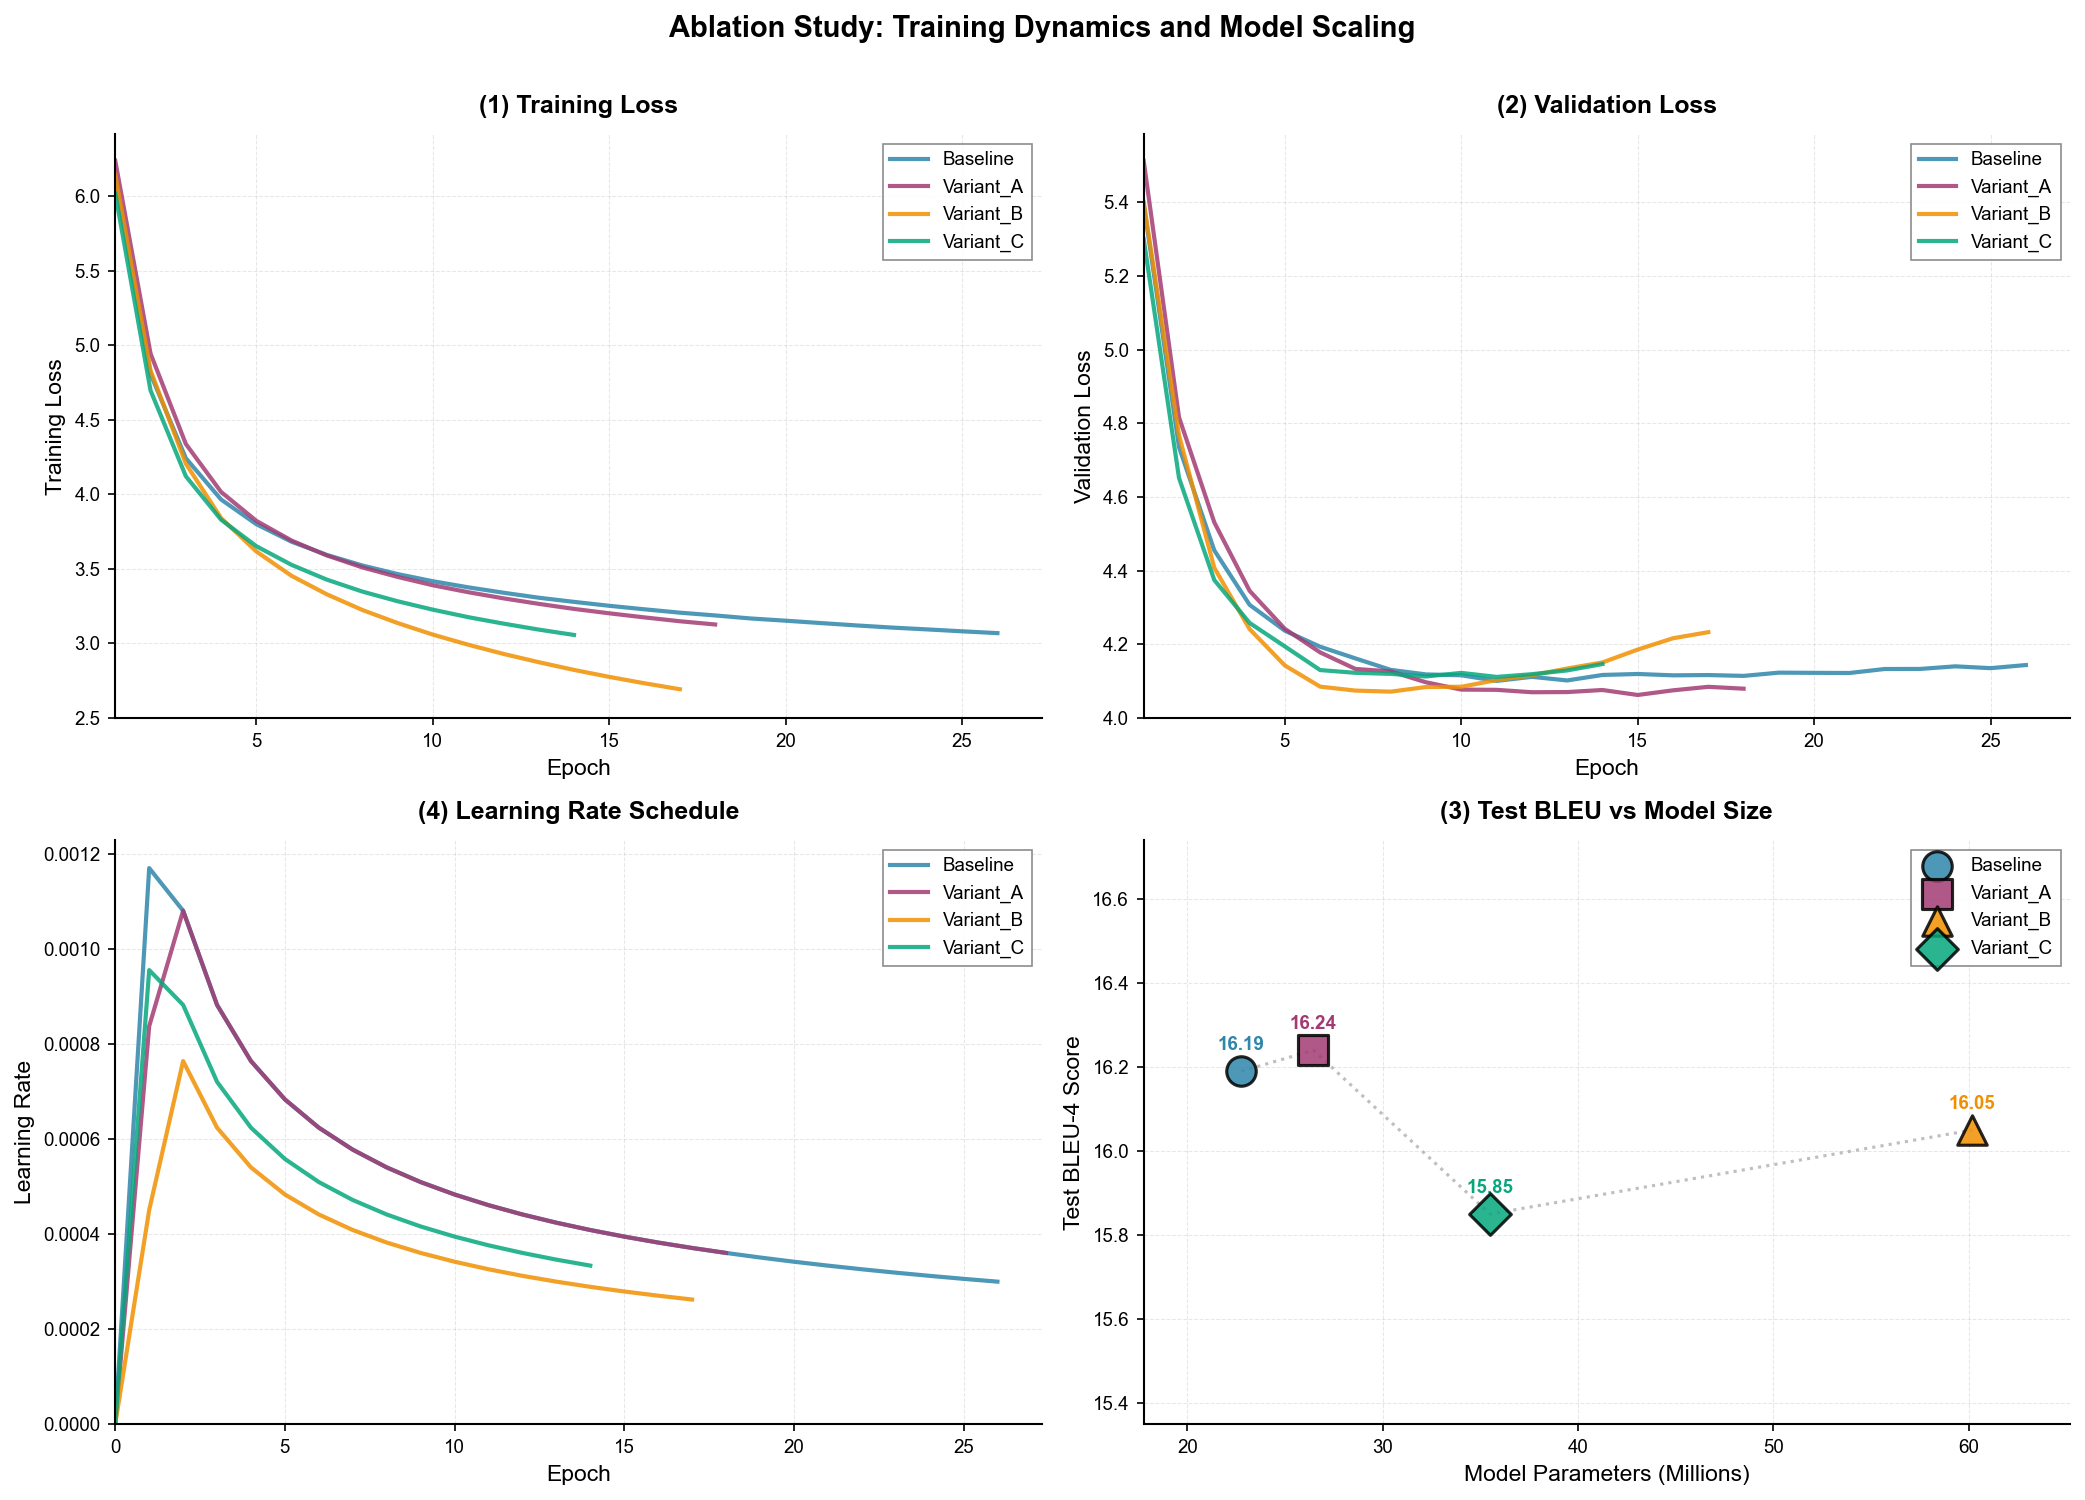


✓ Saved: training_overview_4panel.png (and .pdf)

Figure Layout:
  (1) Training Loss         | (2) Validation Loss
  (4) Learning Rate         | (3) Test BLEU vs Model Size

Key Features:
  • Data loaded from ablation_results.json
  • Learning rate starts from 0 (showing warmup phase)
  • BLEU chart uses test set scores


In [38]:
# ================================================================================
# 学术风格训练曲线可视化 - 从JSON文件读取
# ================================================================================

import matplotlib.pyplot as plt
import numpy as np
import json
from matplotlib import rcParams

# =========================
# 0. 读取JSON数据
# =========================

with open("ablation_results.json", "r", encoding="utf-8") as f:
    ablation_results = json.load(f)

print("✓ Loaded ablation_results.json")
print(f"  Found {len(ablation_results)} experiments: {list(ablation_results.keys())}")

# =========================
# 1. 设置学术风格
# =========================

rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
rcParams['font.size'] = 10
rcParams['axes.labelsize'] = 11
rcParams['axes.titlesize'] = 12
rcParams['xtick.labelsize'] = 9
rcParams['ytick.labelsize'] = 9
rcParams['legend.fontsize'] = 9
rcParams['figure.titlesize'] = 13
rcParams['axes.linewidth'] = 1.0
rcParams['grid.linewidth'] = 0.5
rcParams['lines.linewidth'] = 1.8
rcParams['grid.alpha'] = 0.3
rcParams['grid.linestyle'] = '--'

# =========================
# 2. 配色方案
# =========================

COLOR_SCHEME = {
    "Baseline":  "#2E86AB",
    "Variant_A": "#A23B72",
    "Variant_B": "#F18F01",
    "Variant_C": "#06A77D",
}

LINE_STYLES = {
    "Baseline":  "-",
    "Variant_A": "-",
    "Variant_B": "-",
    "Variant_C": "-",
}

MARKERS = {
    "Baseline":  "o",
    "Variant_A": "s",
    "Variant_B": "^",
    "Variant_C": "D",
}

# =========================
# 3. 辅助函数
# =========================

def setup_axis(ax, xlabel, ylabel, title):
    ax.set_xlabel(xlabel, fontweight='normal')
    ax.set_ylabel(ylabel, fontweight='normal')
    ax.set_title(title, fontweight='bold', pad=10)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.0)
    ax.spines['bottom'].set_linewidth(1.0)

def add_legend(ax, loc='best'):
    legend = ax.legend(
        loc=loc,
        frameon=True,
        fancybox=False,
        shadow=False,
        framealpha=0.9,
        edgecolor='gray',
        facecolor='white'
    )
    legend.get_frame().set_linewidth(0.8)
    return legend

# =========================
# 4. 创建2x2布局
# =========================

names = list(ablation_results.keys())

fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=150)
fig.suptitle(
    "Ablation Study: Training Dynamics and Model Scaling",
    fontsize=14,
    fontweight='bold',
    y=0.995
)

# ─────────────────────────────────────────────────────────
# Figure 1 (0,0): Training Loss
# ─────────────────────────────────────────────────────────

ax = axes[0, 0]
for name in names:
    r = ablation_results[name]
    epochs = range(1, len(r["train_loss_history"]) + 1)
    ax.plot(
        epochs,
        r["train_loss_history"],
        color=COLOR_SCHEME[name],
        linestyle=LINE_STYLES[name],
        linewidth=2.0,
        label=name,
        alpha=0.85
    )

setup_axis(ax, "Epoch", "Training Loss", "(1) Training Loss")
add_legend(ax, loc='upper right')
ax.set_xlim(left=1)
ax.set_ylim(bottom=2.5)

# ─────────────────────────────────────────────────────────
# Figure 2 (0,1): Validation Loss
# ─────────────────────────────────────────────────────────

ax = axes[0, 1]
for name in names:
    r = ablation_results[name]
    epochs = range(1, len(r["val_loss_history"]) + 1)
    ax.plot(
        epochs,
        r["val_loss_history"],
        color=COLOR_SCHEME[name],
        linestyle=LINE_STYLES[name],
        linewidth=2.0,
        label=name,
        alpha=0.85
    )

setup_axis(ax, "Epoch", "Validation Loss", "(2) Validation Loss")
add_legend(ax, loc='upper right')
ax.set_xlim(left=1)
ax.set_ylim(bottom=4.0)

# ─────────────────────────────────────────────────────────
# Figure 3 (1,0): Learning Rate (修复：添加warmup起点)
# ─────────────────────────────────────────────────────────

ax = axes[1, 0]
for name in names:
    r = ablation_results[name]
    
    # 在epoch 0处添加lr=0的起点，显示warmup
    lr_with_warmup = [0.0] + r["lr_history"]
    epochs_with_warmup = range(0, len(lr_with_warmup))
    
    ax.plot(
        epochs_with_warmup,
        lr_with_warmup,
        color=COLOR_SCHEME[name],
        linestyle=LINE_STYLES[name],
        linewidth=2.0,
        label=name,
        alpha=0.85
    )

setup_axis(ax, "Epoch", "Learning Rate", "(4) Learning Rate Schedule")
add_legend(ax, loc='upper right')
ax.set_xlim(left=0)  # 从0开始
ax.set_ylim(bottom=0)  # y轴从0开始，清晰显示warmup

# ─────────────────────────────────────────────────────────
# Figure 4 (1,1): Test BLEU vs Model Size (修复：使用测试集BLEU)
# ─────────────────────────────────────────────────────────

ax = axes[1, 1]

# 提取数据 - 使用测试集BLEU
params_list = [ablation_results[n]["params_M"] for n in names]
test_bleu_list = [ablation_results[n]["test_bleu"] for n in names]  # 使用test_bleu

# 绘制散点图
for i, name in enumerate(names):
    ax.scatter(
        params_list[i],
        test_bleu_list[i],
        color=COLOR_SCHEME[name],
        s=200,
        marker=MARKERS[name],
        edgecolors='black',
        linewidths=1.5,
        alpha=0.85,
        zorder=5,
        label=name
    )
    
    # 添加数值标注
    ax.annotate(
        f'{test_bleu_list[i]:.2f}',
        xy=(params_list[i], test_bleu_list[i]),
        xytext=(0, 10),
        textcoords='offset points',
        ha='center',
        fontsize=9,
        color=COLOR_SCHEME[name],
        fontweight='bold'
    )

# 可选：添加连线显示趋势
sorted_indices = sorted(range(len(params_list)), key=lambda i: params_list[i])
sorted_params = [params_list[i] for i in sorted_indices]
sorted_bleu = [test_bleu_list[i] for i in sorted_indices]
ax.plot(sorted_params, sorted_bleu, 
        color='gray', linestyle=':', linewidth=1.5, alpha=0.5, zorder=1)

setup_axis(ax, "Model Parameters (Millions)", "Test BLEU-4 Score", 
           "(3) Test BLEU vs Model Size")
add_legend(ax, loc='best')
ax.set_xlim(left=min(params_list) - 5, right=max(params_list) + 5)
ax.set_ylim(bottom=min(test_bleu_list) - 0.5, top=max(test_bleu_list) + 0.5)

# =========================
# 5. 保存图片
# =========================

plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.savefig("training_overview_4panel.png", dpi=300, bbox_inches="tight")
plt.savefig("training_overview_4panel.pdf", bbox_inches="tight")
plt.show()

print("\n" + "=" * 80)
print("✓ Saved: training_overview_4panel.png (and .pdf)")
print("=" * 80)
print("\nFigure Layout:")
print("  (1) Training Loss         | (2) Validation Loss")
print("  (4) Learning Rate         | (3) Test BLEU vs Model Size")
print("\nKey Features:")
print("  • Data loaded from ablation_results.json")
print("  • Learning rate starts from 0 (showing warmup phase)")
print("  • BLEU chart uses test set scores")
print("=" * 80)